Error: 0.11396706380375499


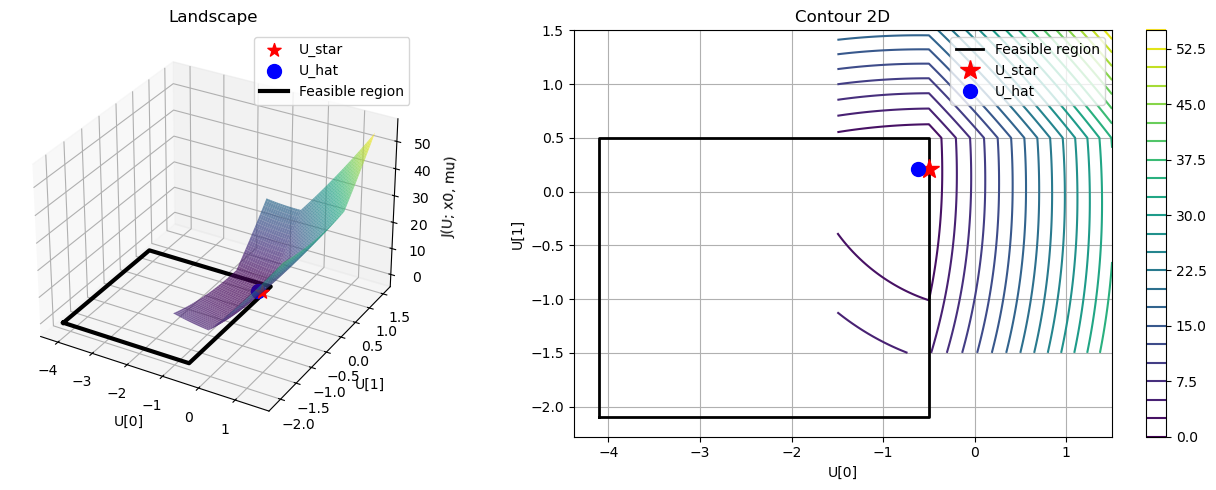

In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(9)

# QP param
x0 = np.array([0.5, -0.3])
P = np.array([[1.0, 0.2],
              [0.2, 1.5]])
S = np.array([[0.8, -0.4],
              [-0.3, 0.6]])
H = np.array([[2.0, 0.5],
              [0.5, 3.0]])
u_bar = np.array([-4.1, -2.1])
u_bar_upper = np.array([-0.5, 0.5])

def J0(U, x0):
    return x0 @ P @ x0 + x0 @ S @ U + 0.5 * U @ H @ U

def phi(U):
    return np.sum(np.maximum(0, U - u_bar_upper)) + np.sum(np.maximum(0, u_bar - U))

# mu_safe (Theorem 1)
x_max = np.linalg.norm(x0, np.inf)
u_limit = max(np.linalg.norm(u_bar, np.inf), np.linalg.norm(u_bar_upper, np.inf))
H_inf_norm = np.max(np.sum(np.abs(H), axis=1))
S_1_norm = np.max(np.sum(np.abs(S), axis=0))
mu_safe = H_inf_norm * u_limit + S_1_norm * x_max

# cvxpy solve
U = cp.Variable(2)
objective = cp.Minimize(x0 @ P @ x0 + x0 @ S @ U + 0.5 * cp.quad_form(U, H))
constraints = [U >= u_bar, U <= u_bar_upper]
prob = cp.Problem(objective, constraints)
prob.solve()
U_star = U.value

# Variational parameters
lam = 0.1
mu = mu_safe * 1.05
K = 100000
samples = np.random.multivariate_normal(np.zeros(2), 2.0 * np.eye(2), K)


J_vals = np.array([J0(U_sample, x0) + mu * phi(U_sample) for U_sample in samples])
weights = np.exp(-J_vals / lam)
weights = weights / weights.sum()

U_hat = (samples.T @ weights).T

print("Error:", np.linalg.norm(U_star - U_hat))

# 3D surface plot
u1 = np.linspace(-1.5, 1.5, 100)
u2 = np.linspace(-1.5, 1.5, 100)
U1, U2 = np.meshgrid(u1, u2)
Z = np.zeros_like(U1)
for i in range(len(u1)):
    for j in range(len(u2)):
        U_ij = np.array([U1[j, i], U2[j, i]])
        Z[j, i] = J0(U_ij, x0) + mu * phi(U_ij)
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(U1, U2, Z, cmap='viridis', alpha=0.7, edgecolor='none')
ax1.scatter([U_star[0]], [U_star[1]], [J0(U_star, x0) + mu*phi(U_star)], color='red', s=100, marker='*', label='U_star')
ax1.scatter([U_hat[0]], [U_hat[1]], [J0(U_hat, x0) + mu*phi(U_hat)], color='blue', s=100, marker='o', label='U_hat')
z_box = np.min(Z) - 1
box_x = [u_bar[0], u_bar_upper[0], u_bar_upper[0], u_bar[0], u_bar[0]]
box_y = [u_bar[1], u_bar[1], u_bar_upper[1], u_bar_upper[1], u_bar[1]]
ax1.plot(box_x, box_y, [z_box]*5, 'k-', linewidth=3, label='Feasible region')
ax1.set_xlabel('U[0]')
ax1.set_ylabel('U[1]')
ax1.set_zlabel('J(U; x0, mu)')
ax1.set_title('Landscape')
ax1.legend()
ax2 = fig.add_subplot(122)
contour = ax2.contour(U1, U2, Z, levels=25, cmap='viridis')
ax2.plot(box_x, box_y, 'k-', linewidth=2, label='Feasible region')
ax2.plot(U_star[0], U_star[1], 'r*', markersize=15, label='U_star')
ax2.plot(U_hat[0], U_hat[1], 'bo', markersize=10, label='U_hat')
ax2.set_xlabel('U[0]')
ax2.set_ylabel('U[1]')
ax2.set_title('Contour 2D')
ax2.legend()
ax2.grid(True)
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()